## Panning an oscillator's output

This example demonstrates modulated stereo panning using an LFO (Low Frequency Oscillator).
The pan position oscillates between left and right at 4 Hz, creating an auto-panning effect.

Note: Fixed to properly advance the modulator in vectorized mode.


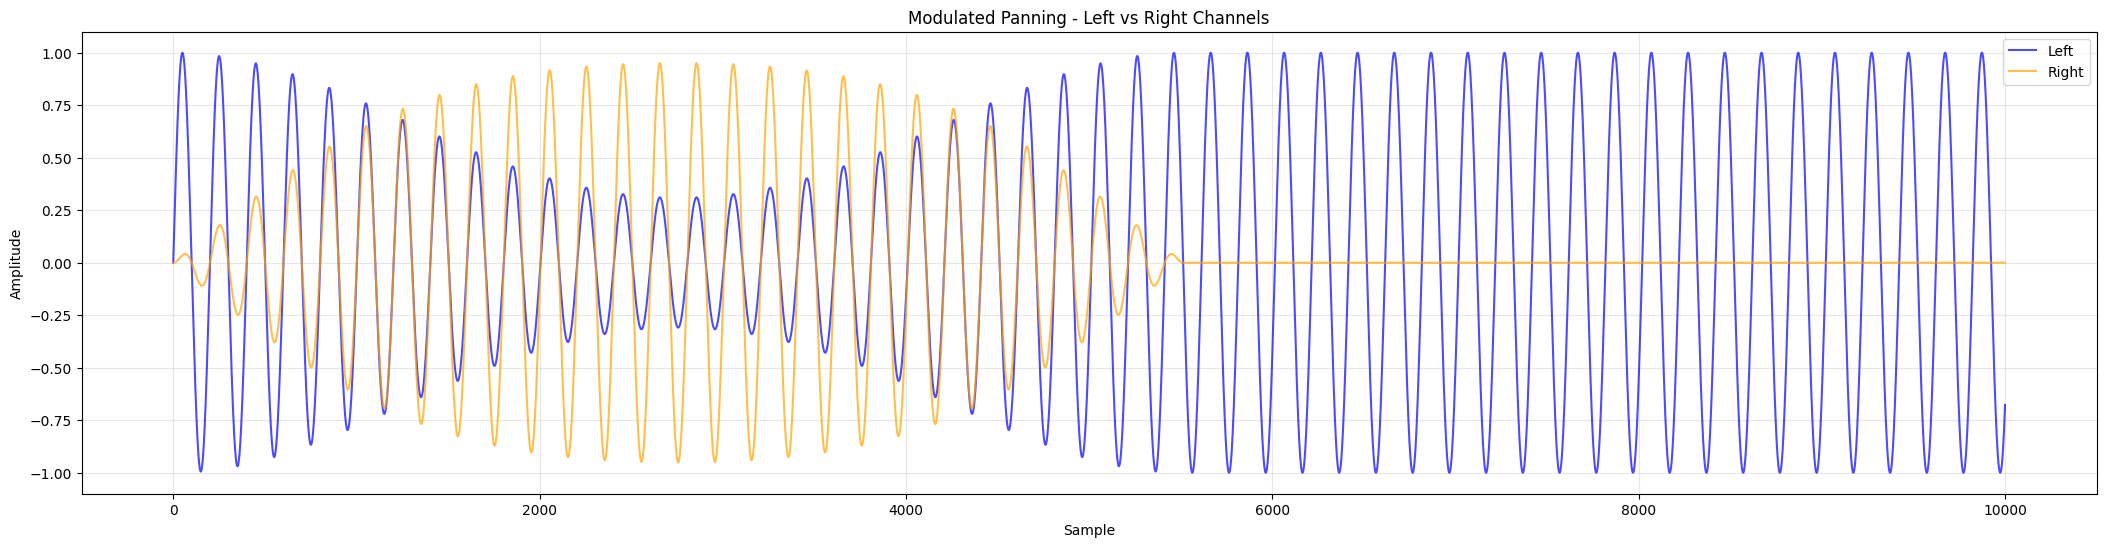

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from engine import SineOscillator, ModulatedPanner, Chain

# Create a 220Hz sine wave with auto-panning at 4Hz
gen = Chain(
    SineOscillator(220),
    ModulatedPanner(SineOscillator(4, wave_range=(-0.8, 0.8)))
)

plt.figure(figsize=(26, 6))
wav = gen.get_samples(10000)
l, r = np.array(wav).T

plt.plot(l, label="Left", color="blue", alpha=0.7)
plt.plot(r, label="Right", color="orange", alpha=0.7)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Modulated Panning - Left vs Right Channels")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.show()




In [2]:
# Verify channels are different
print(f"Channels are different: {not np.allclose(l, r)}")
print(f"Left channel range: [{l.min():.4f}, {l.max():.4f}]")
print(f"Right channel range: [{r.min():.4f}, {r.max():.4f}]")

Channels are different: True
Left channel range: [-1.0000, 1.0000]
Right channel range: [-0.9510, 0.9504]
